In [81]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [82]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [83]:
import pandas as pd
import numpy as np
import pyspark as psp
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import shap





In [130]:

data_path = r"input/playground-series-s5e10"

In [131]:
df_train = pd.read_csv((data_path + r"/train.csv"))
df_train.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56
5,5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0,0.61
6,6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2,0.20
7,7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0,0.16
8,8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2,0.18
9,9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2,0.15


In [132]:
df_test = pd.read_csv((data_path + r"/test.csv"))
df_test.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3
5,517759,highway,2,0.52,25,night,rainy,True,True,morning,False,True,1
6,517760,rural,4,0.17,70,dim,clear,True,False,afternoon,True,True,0
7,517761,urban,3,0.62,25,daylight,clear,False,True,afternoon,True,False,0
8,517762,highway,3,0.93,45,dim,rainy,True,True,evening,True,False,2
9,517763,urban,1,0.97,35,daylight,clear,True,True,evening,False,True,2


In [133]:
print("percentage of nulls in train :")
(df_train.isna().sum().sum()/len(df_train))*100

percentage of nulls in train :


np.float64(0.0)

In [134]:
print("percentage of nulls in w test:")
(df_test.isna().sum().sum()/len(df_test))*100

percentage of nulls in w test:


np.float64(0.0)

Im going to change not numerical columns into numerical in both train and test, but to keep consistance uzing the same encoder, but for test only transform.

In [136]:
feature_mappings = {}

for feature in ['road_type', 'lighting', 'weather', 'road_signs_present', 
                'public_road', 'time_of_day', 'holiday', 'school_season']:
    
    le = LabelEncoder()
    
    train_encoded = le.fit_transform(df_train[feature])
    df_train[f"{feature}_value"] = train_encoded
    
    feature_mappings[feature] = {
        'encoder': le,
        'mapping': dict(zip(le.classes_, le.transform(le.classes_)))
    }

    test_values = []
    for value in df_test[feature]:
        if value in le.classes_:
            test_values.append(le.transform([value])[0])
        else:
            test_values.append(-1)  
            print(f"If additional: {value} in column {feature}")
    
    df_test[f"{feature}_value"] = test_values

# Sprawdź mappingi
print("\n Presentation of mappings:")
for feature, mapping_info in feature_mappings.items():
    print(f"{feature}: {mapping_info['mapping']}")


 Presentation of mappings:
road_type: {'highway': np.int64(0), 'rural': np.int64(1), 'urban': np.int64(2)}
lighting: {'daylight': np.int64(0), 'dim': np.int64(1), 'night': np.int64(2)}
weather: {'clear': np.int64(0), 'foggy': np.int64(1), 'rainy': np.int64(2)}
road_signs_present: {np.False_: np.int64(0), np.True_: np.int64(1)}
public_road: {np.False_: np.int64(0), np.True_: np.int64(1)}
time_of_day: {'afternoon': np.int64(0), 'evening': np.int64(1), 'morning': np.int64(2)}
holiday: {np.False_: np.int64(0), np.True_: np.int64(1)}
school_season: {np.False_: np.int64(0), np.True_: np.int64(1)}


Some checks of datatype

In [137]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        517754 non-null  int64  
 1   road_type                 517754 non-null  object 
 2   num_lanes                 517754 non-null  int64  
 3   curvature                 517754 non-null  float64
 4   speed_limit               517754 non-null  int64  
 5   lighting                  517754 non-null  object 
 6   weather                   517754 non-null  object 
 7   road_signs_present        517754 non-null  bool   
 8   public_road               517754 non-null  bool   
 9   time_of_day               517754 non-null  object 
 10  holiday                   517754 non-null  bool   
 11  school_season             517754 non-null  bool   
 12  num_reported_accidents    517754 non-null  int64  
 13  accident_risk             517754 non-null  f

In [138]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172585 entries, 0 to 172584
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        172585 non-null  int64  
 1   road_type                 172585 non-null  object 
 2   num_lanes                 172585 non-null  int64  
 3   curvature                 172585 non-null  float64
 4   speed_limit               172585 non-null  int64  
 5   lighting                  172585 non-null  object 
 6   weather                   172585 non-null  object 
 7   road_signs_present        172585 non-null  bool   
 8   public_road               172585 non-null  bool   
 9   time_of_day               172585 non-null  object 
 10  holiday                   172585 non-null  bool   
 11  school_season             172585 non-null  bool   
 12  num_reported_accidents    172585 non-null  int64  
 13  road_type_value           172585 non-null  i

In [139]:

numerical_columns_train = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_columns_test = df_test.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(numerical_columns_train)
print(numerical_columns_test)

['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk', 'road_type_value', 'lighting_value', 'weather_value', 'road_signs_present_value', 'public_road_value', 'time_of_day_value', 'holiday_value', 'school_season_value']
['id', 'num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents', 'road_type_value', 'lighting_value', 'weather_value', 'road_signs_present_value', 'public_road_value', 'time_of_day_value', 'holiday_value', 'school_season_value']


in test we do not have accident_risk for validation will use train as a main dataset and will create train and test from it.

In [140]:


df_train_cars = df_train[numerical_columns_train]


X = df_train_cars.drop(columns=['accident_risk'])
y = df_train_cars['accident_risk']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'max_depth': [3, 5, 7, 10],  
    'min_child_weight': [1, 3, 5],  
    'subsample': [0.7, 0.8, 0.9, 1.0],  
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  
    'alpha': [0.1, 0.3, 0.5],  
    'lambda': [1,3,5]  
}


model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring='neg_mean_squared_error', cv=5, verbose=2, n_jobs=-1, random_state=42)

random_search.fit(X_train_scaled, y_train)

print(f'Best parameters: {random_search.best_params_}')
print(f'Best score: {random_search.best_score_}')

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 150, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.05, 'lambda': 1, 'colsample_bytree': 1.0, 'alpha': 0.5}
Best score: -0.003141895062617987
Mean Squared Error: 0.003160780464028114
                     Feature  Importance
6             lighting_value    0.520539
3                speed_limit    0.298718
2                  curvature    0.082733
7              weather_value    0.070734
4     num_reported_accidents    0.024277
11             holiday_value    0.000899
9          public_road_value    0.000804
8   road_signs_present_value    0.000272
1                  num_lanes    0.000269
10         time_of_day_value    0.000222
5            road_type_value    0.000191
0                         id    0.000176
12       school_season_value    0.000165


For validation will do some checks, and also wanted to check witch of parameter have the biggest influence for model.

In [141]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R² score: {r2:.4f}")

# Interpretacja R²:
# 0.9-1.0: perfect, might be overffit
# 0.8-0.9: v.good
# 0.7-0.8: good
# 0.6-0.7: ok
# < 0.6: bad

R² score: 0.8855


<Axes: >

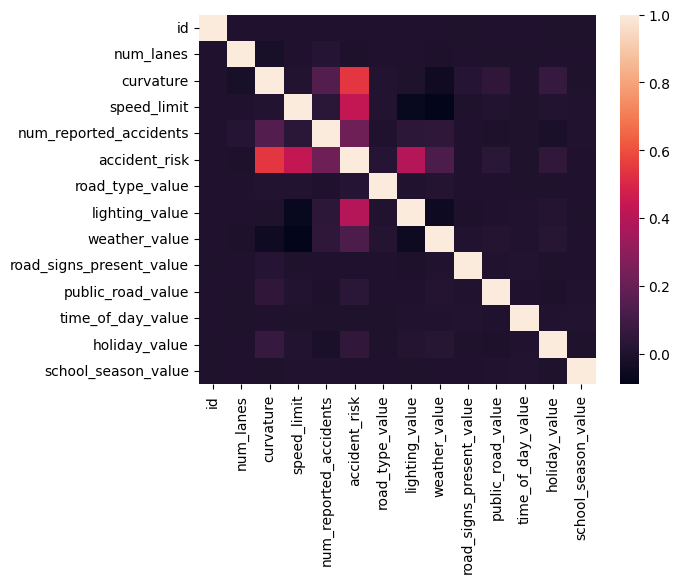

In [142]:
correlation = df_train_cars.corr() 
sns.heatmap(correlation)


In [149]:

df_test_cars = df_test[numerical_columns_test]

X_test_test = scaler.transform(df_test_cars)

predictions_test_y = best_model.predict(X_test_test)

df_test['accident_risk'] = predictions_test_y

df_test.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,...,num_reported_accidents,road_type_value,lighting_value,weather_value,road_signs_present_value,public_road_value,time_of_day_value,holiday_value,school_season_value,accident_risk
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,...,1,0,2,0,1,1,0,1,1,0.292235
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,...,0,2,1,1,1,0,0,1,0,0.124340
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,...,1,2,1,0,1,0,0,1,1,0.185105
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,...,2,1,0,2,0,0,0,0,0,0.322360
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,...,3,0,0,0,1,0,1,0,1,0.409445
5,517759,highway,2,0.52,25,night,rainy,True,True,morning,...,1,0,2,2,1,1,2,0,1,0.463696
6,517760,rural,4,0.17,70,dim,clear,True,False,afternoon,...,0,1,1,0,1,0,0,1,1,0.259691
7,517761,urban,3,0.62,25,daylight,clear,False,True,afternoon,...,0,2,0,0,0,1,0,1,0,0.199640
8,517762,highway,3,0.93,45,dim,rainy,True,True,evening,...,2,0,1,2,1,1,1,1,0,0.364237
9,517763,urban,1,0.97,35,daylight,clear,True,True,evening,...,2,2,0,0,1,1,1,0,1,0.328208


In [150]:
submission_file_KK = df_test[['id', 'accident_risk']]

submission_file_KK.head()

,id,accident_risk
0,517754,0.292235
1,517755,0.124340
2,517756,0.185105
3,517757,0.322360
4,517758,0.409445


In [151]:
submission_file_KK.to_csv("submission_file_KK.csv", index=False)